In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

In [90]:
engine = create_engine("Your rds connection endpoint")

In [7]:
df = pd.read_sql("SELECT * FROM gold.unified_oglasi",engine)

In [8]:
print(f"Broj oglasa: {len(df)}")
print(f"Kolone: {df.columns.tolist()}")

Broj oglasa: 23431
Kolone: ['unified_id', 'izvor', 'oglas_id', 'url', 'title', 'price_total', 'price_per_m2', 'tip_nekretnine', 'kvadratura', 'broj_soba', 'oglasivac', 'tip_objekta', 'stanje_objekta', 'grejanje', 'sprat', 'ukupna_spratnost', 'uknjizen', 'terasa', 'interfon', 'klima', 'video_nadzor', 'internet', 'parking', 'garaza', 'lift', 'podrum', 'linije_gradskog_prevoza', 'datum_objave', 'lokacija', 'created_at']


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23431 entries, 0 to 23430
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   unified_id               23431 non-null  str           
 1   izvor                    23431 non-null  str           
 2   oglas_id                 23431 non-null  str           
 3   url                      23431 non-null  str           
 4   title                    23034 non-null  str           
 5   price_total              22962 non-null  float64       
 6   price_per_m2             22976 non-null  float64       
 7   tip_nekretnine           19552 non-null  str           
 8   kvadratura               23016 non-null  float64       
 9   broj_soba                22877 non-null  float64       
 10  oglasivac                11306 non-null  str           
 11  tip_objekta              6814 non-null   str           
 12  stanje_objekta           16833 non-null  st

In [10]:
null_values = (df.isnull().sum() / len(df) * 100).sort_values(ascending = False)
print(null_values.round(1))

video_nadzor               83.3
podrum                     80.2
garaza                     75.3
tip_objekta                70.9
linije_gradskog_prevoza    69.4
parking                    60.2
internet                   56.4
oglasivac                  51.7
klima                      49.5
ukupna_spratnost           48.6
uknjizen                   46.5
lift                       44.2
interfon                   35.4
stanje_objekta             28.2
terasa                     25.2
tip_nekretnine             16.6
datum_objave               16.2
grejanje                    8.8
sprat                       8.2
broj_soba                   2.4
lokacija                    2.1
price_total                 2.0
price_per_m2                1.9
kvadratura                  1.8
title                       1.7
unified_id                  0.0
izvor                       0.0
url                         0.0
oglas_id                    0.0
created_at                  0.0
dtype: float64


<Axes: >

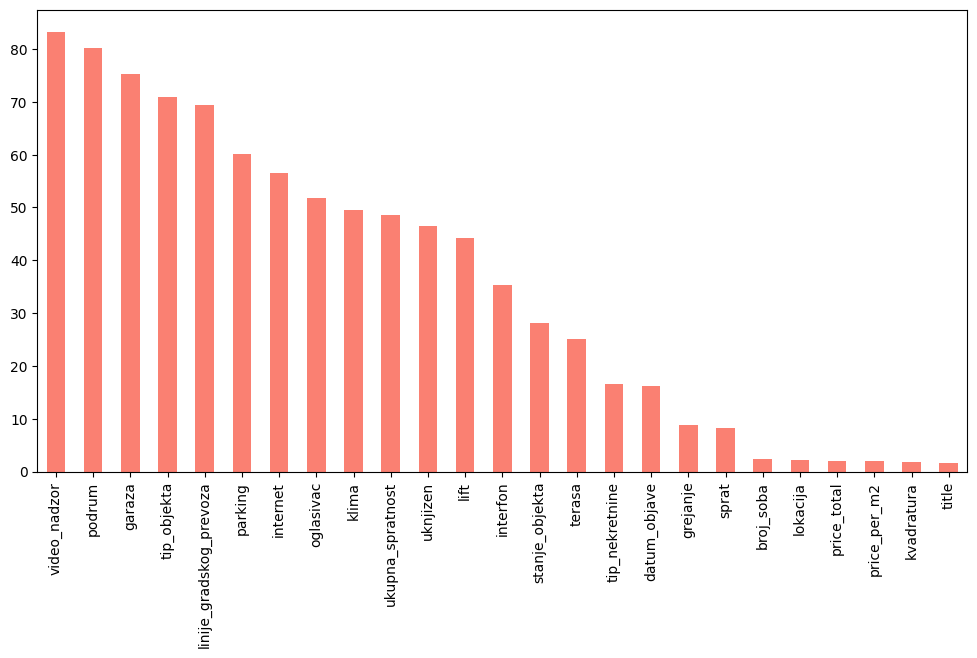

In [11]:
plt.figure(figsize = (12,6))
null_values[null_values > 0].plot(kind = "bar",color = "salmon")

In [12]:
kljucne_kolone = ["title","lokacija","price_total", "price_per_m2", "kvadratura", "broj_soba", "sprat"]
df[kljucne_kolone].describe().round(2)

,price_total,price_per_m2,kvadratura,broj_soba,sprat
count,2.296200e+04,22976.00,23016.00,22877.00,21509.00
mean,3.168308e+08,27899.30,78.98,2.83,3.25
std,4.542887e+10,533104.48,48.68,1.13,3.44
min,1.000000e+00,2.00,1.00,0.50,-1.00
25%,1.500000e+05,3300.00,51.00,2.00,1.00
50%,2.240000e+05,8270.00,68.00,3.00,2.00
75%,3.349150e+05,33692.00,94.00,3.50,4.00
max,6.880002e+12,42504500.00,2927.00,20.00,39.00


In [13]:
print("Najskuplji oglasi:")
print(df.nlargest(5, "price_total")[["title", "price_total", "kvadratura", "lokacija", "izvor"]])

print("\nNajjeftiniji oglasi:")
print(df.nsmallest(5, "price_total")[["title", "price_total", "kvadratura", "lokacija", "izvor"]])

Najskuplji oglasi:
                                                 title   price_total  \
14911                                        MAGLAJSKA  6.880002e+12   
15420                     NOVOGRADNJA Veselina Masleše  1.633453e+11   
20669  Vukov Spomenik (Ruzveltova ulica) BANAT GRADNJA  1.470304e+11   
14259                PRODAJA LUX STANOVA U NOVOGRADNJI  7.800037e+10   
20654                              HUMSKA  NOVOGRADNJA  4.250450e+07   

       kvadratura   lokacija          izvor  
14911         NaN  Nepoznato  nekretnine_rs  
15420         NaN   Vozdovac  nekretnine_rs  
20669      125.00     Centar  nekretnine_rs  
14259       65.29   Cukarica  nekretnine_rs  
20654       46.35  Hajd Park  nekretnine_rs  

Najjeftiniji oglasi:
                                          title  price_total  kvadratura  \
10030      Dvosoban stan na prodaju, Sarajevska          1.0        56.0   
15776                     Kotez jednosoban stan         35.0        14.5   
14506  Jajinci-U IZGRA

In [14]:
# Cena: 10,000 EUR – 5,000,000 EUR
# Kvadratura: 15m² – 700m²
# Cena po m²: 500 EUR – 20,000 EUR

df_clean = df[
    (df["price_total"].between(10_000, 5_000_000)) &
    (df["kvadratura"].between(15, 700)) &
    (df["price_per_m2"].between(500, 20_000))
].copy()

print(f"Originalno: {len(df)} oglasa")
print(f"Nakon filtriranja: {len(df_clean)} oglasa")
print(f"Uklonjeno: {len(df) - len(df_clean)} oglasa ({(len(df) - len(df_clean)) / len(df) * 100:.1f}%)")

Originalno: 23431 oglasa
Nakon filtriranja: 12386 oglasa
Uklonjeno: 11045 oglasa (47.1%)


In [15]:
# Pogledaj distribuciju cena da vidimo gde su realne vrednosti
print("price_total percentili:")
print(df["price_total"].quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).round(0))

print("\nprice_per_m2 percentili:")
print(df["price_per_m2"].quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).round(0))

print("\nkvadratura percentili:")
print(df["kvadratura"].quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).round(0))

price_total percentili:
0.01      59538.0
0.05      88820.0
0.10     107011.0
0.25     150000.0
0.50     224000.0
0.75     334915.0
0.90     515400.0
0.95     695000.0
0.99    1270000.0
Name: price_total, dtype: float64

price_per_m2 percentili:
0.01     1500.0
0.05     2031.0
0.10     2450.0
0.25     3300.0
0.50     8270.0
0.75    33692.0
0.90    44972.0
0.95    51742.0
0.99    69244.0
Name: price_per_m2, dtype: float64

kvadratura percentili:
0.01     25.0
0.05     33.0
0.10     39.0
0.25     51.0
0.50     68.0
0.75     94.0
0.90    130.0
0.95    160.0
0.99    236.0
Name: kvadratura, dtype: float64


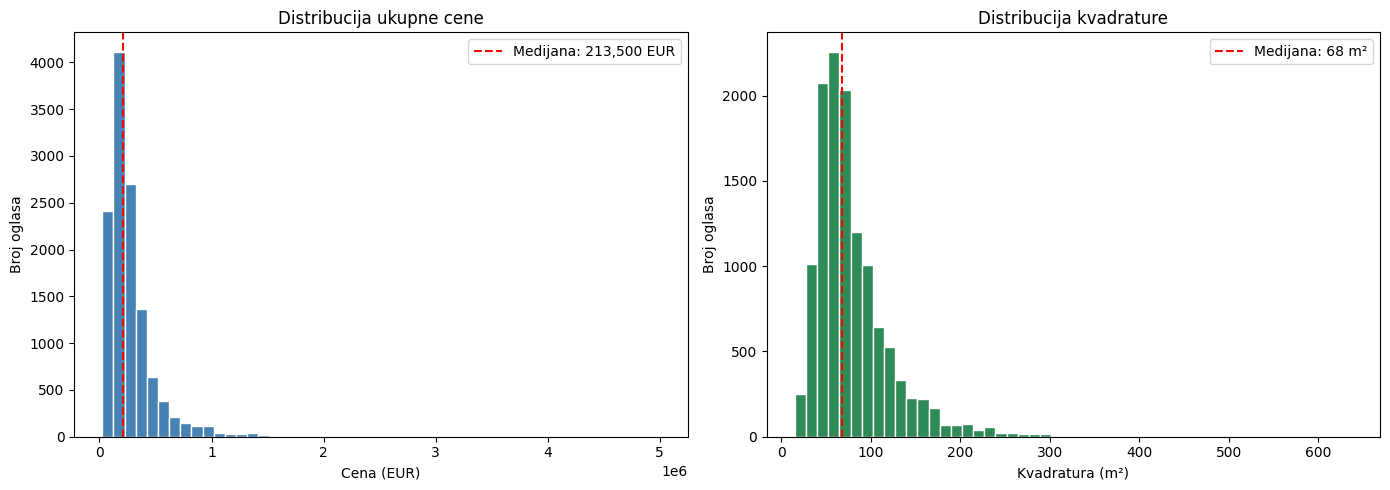

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribucija ukupne cene
axes[0].hist(df_clean["price_total"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribucija ukupne cene")
axes[0].set_xlabel("Cena (EUR)")
axes[0].set_ylabel("Broj oglasa")
axes[0].axvline(df_clean["price_total"].median(), color="red", linestyle="--", label=f'Medijana: {df_clean["price_total"].median():,.0f} EUR')
axes[0].legend()

# Distribucija kvadrature
axes[1].hist(df_clean["kvadratura"].dropna(), bins=50, color="seagreen", edgecolor="white")
axes[1].set_title("Distribucija kvadrature")
axes[1].set_xlabel("Kvadratura (m²)")
axes[1].set_ylabel("Broj oglasa")
axes[1].axvline(df_clean["kvadratura"].median(), color="red", linestyle="--", label=f'Medijana: {df_clean["kvadratura"].median():,.0f} m²')
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
# Broj oglasa i medijana cene po izvoru
print(df_clean.groupby("izvor")[["price_total", "kvadratura"]].median().round(0))

               price_total  kvadratura
izvor                                 
halo_oglasi       114000.0        66.0
nekretnine_rs     225000.0        68.0
z4ida             110136.0        63.0


In [18]:
losi_price_per_m2 = df[
    (df["price_per_m2"] > 6000) &
    (df["price_per_m2"].notna())
    ].sort_values("price_per_m2",ascending = False)

print(f"Broj losih oglasa sa price_per_m2: {len(losi_price_per_m2)}")
pd.set_option("display.max_colwidth", None)
losi_price_per_m2[["url","price_total","price_per_m2","kvadratura","izvor"]].head(20)

Broj losih oglasa sa price_per_m2: 11919


,url,price_total,price_per_m2,kvadratura,izvor
20654,https://www.nekretnine.rs/stambeni-objekti/stanovi/humska-10-novogradnja/NkD39xa5KBQ/,4.250450e+07,42504500.0,46.35,nekretnine_rs
20669,https://www.nekretnine.rs/stambeni-objekti/stanovi/vukov-spomenik-ruzveltova-ulica-125m2-banat-gradnja/NkVDgU7HLF-/,1.470304e+11,39004500.0,125.00,nekretnine_rs
14558,https://www.nekretnine.rs/stambeni-objekti/stanovi/-alterra-versa-luxury-smart-home-/NkEcIcB3pbd/,3.300350e+07,33003500.0,NaN,nekretnine_rs
14259,https://www.nekretnine.rs/stambeni-objekti/stanovi/prodaja-lux-stanova-u-novogradnji/NkzdXNAjsiA/,7.800037e+10,30003000.0,65.29,nekretnine_rs
20655,https://www.nekretnine.rs/stambeni-objekti/stanovi/stambeno-poslovni-kompleks-vidikovac-vista/Nkpq3PrBFcB/,2.700320e+07,27003200.0,NaN,nekretnine_rs
20274,https://www.nekretnine.rs/stambeni-objekti/stanovi/asta-residence---novogradnja-u-srcu-beograda/NkDKA5lNbgZ/,2.200278e+07,22002780.0,NaN,nekretnine_rs
4969,https://www.halooglasi.com/nekretnine/prodaja-stanova/st-regis-dizajnerski-opremljen-stan-na-33-spr/5425646947866?kid=1&sid=1775835181180,1.470000e+06,200002.0,73.00,halo_oglasi
178,https://www.halooglasi.com/nekretnine/prodaja-stanova/st-regis---lux-2-0-stan-sa-garaznim-mestom/5425646979174?kid=4&sid=1775767324375,1.500000e+06,198652.0,74.00,halo_oglasi
177,https://www.halooglasi.com/nekretnine/prodaja-stanova/st-regis---lux-5-0-stan-sa-dva-garazna-mesta/5425646979175?kid=4&sid=1775767324375,1.450000e+05,187762.0,147.00,halo_oglasi
1898,https://www.halooglasi.com/nekretnine/prodaja-stanova/bw-st-regis-bw-kula-2-0-lux/5425646449478?kid=3&sid=1775835181180,5.900000e+05,119922.0,61.04,halo_oglasi


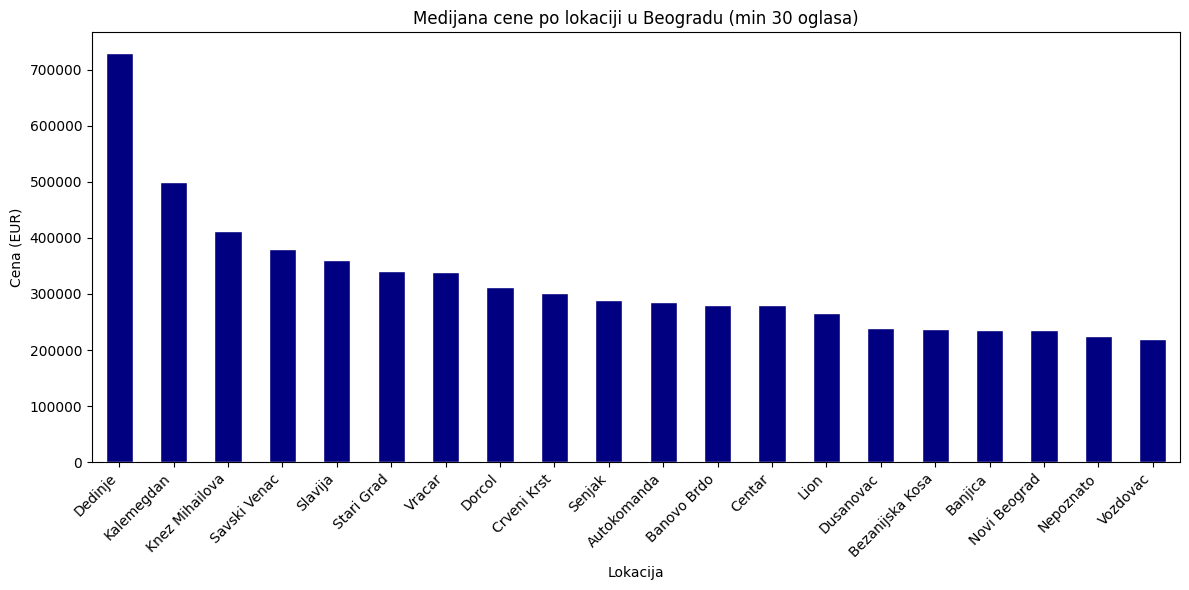

                   median  count
lokacija                        
Dedinje          730000.0     98
Kalemegdan       500000.0     73
Knez Mihailova   412000.0     64
Savski Venac     381000.0    214
Slavija          360000.0     48
Stari Grad       340500.0    196
Vracar           339000.0    829
Dorcol           312000.0    136
Crveni Krst      302000.0    104
Senjak           288888.0     51
Autokomanda      285000.0    111
Banovo Brdo      280000.0    188
Centar           280000.0    481
Lion             265284.0     50
Dusanovac        240000.0     47
Bezanijska Kosa  237596.0     52
Banjica          235000.0     44
Novi Beograd     235000.0    387
Nepoznato        225000.0   4465
Vozdovac         220000.0    400


In [34]:
cene_po_lokaciji = (
    df_clean.groupby("lokacija")["price_total"]
    .agg(["median","count"])
    .query("count >= 30")
    .sort_values("median",ascending = False)
    .head(15)
)

plt.figure(figsize= (12,6))
cena_po_lokaciji["median"].plot(kind = "bar",color = "navy",edgecolor = "white")
plt.title("Medijana cene po lokaciji u Beogradu (min 30 oglasa)")
plt.xlabel("Lokacija")
plt.ylabel("Cena (EUR)")
plt.xticks(rotation = 45,ha= "right")
plt.tight_layout()
plt.show()

print(cena_po_lokaciji)

In [35]:
cena_po_m2 = (
    df_clean.groupby("lokacija")["price_per_m2"]
    .agg(["median","count"])
    .query("count >= 30")
    .sort_values("median",ascending = False)
    .head(15)
)

print(cena_po_m2)

                 median  count
lokacija                      
Mladenovac      15302.0     53
Kalemegdan       5669.0     73
Knez Mihailova   5125.0     64
Dedinje          5000.0     98
Dorcol           4738.0    136
Savski Venac     4493.5    214
Centar           4356.0    481
Stari Grad       4343.5    196
Vracar           4310.0    829
Slavija          4003.0     48
Senjak           3904.0     51
Crveni Krst      3833.0    104
Lion             3778.5     50
Hadzipopovac     3700.0     36
Nepoznato        3600.0   4465


In [50]:
df_clean[df_clean["lokacija"] == "Mladenovac"][["title", "price_total", "kvadratura", "lokacija", "url"]].sort_values("price_total",ascending = False).head(20)

,title,price_total,kvadratura,lokacija,url
377,"Nov, luksuzan, stan , Mladenovac, dupleks",619000.0,135.00,Mladenovac,https://www.halooglasi.com/nekretnine/prodaja-stanova/nov-luksuzan-stan-135m2-mladenovac-dupleks/5425645608951?kid=3&sid=1775778589540
10692,"Petosoban stan na prodaju, Mladenovačka",330000.0,178.00,Mladenovac,https://www.4zida.rs/prodaja-stanova/banovo-brdo-cukarica-opstina-beograd/petosoban-stan/6380aa4b763ad3d2810dc413
8582,"Četvoroiposoban stan na prodaju, Mladenovac (mesto)",214200.0,135.00,Mladenovac,https://www.4zida.rs/prodaja-stanova/mladenovac-mesto-mladenovac-opstina-beograd/cetvoroiposoban-stan/6841436454b5937f3705f308
11408,"Četvorosoban stan na prodaju, Mladenovac (mesto)",210000.0,127.00,Mladenovac,https://www.4zida.rs/prodaja-stanova/mladenovac-mesto-mladenovac-opstina-beograd/cetvorosoban-stan/69dc9068508a7c1b900fc313
3839,"Mladenovac, lux duplex",160000.0,135.00,Mladenovac,https://www.halooglasi.com/nekretnine/prodaja-stanova/mladenovac-lux-duplex-135-m2/5425646964310?kid=1&sid=1775835181180
8585,"Četvoroiposoban stan na prodaju, Mladenovac (mesto)",139000.0,122.00,Mladenovac,https://www.4zida.rs/prodaja-stanova/mladenovac-mesto-mladenovac-opstina-beograd/cetvoroiposoban-stan/687ba65f6697a5820b0b0873
2431,"Trosoban stan, Mladenovac",129700.0,83.00,Mladenovac,https://www.halooglasi.com/nekretnine/prodaja-stanova/trosoban-stan-mladenovac/5425646439415?kid=1&sid=1775835181180
7113,"Mladenovac Centar, Dupleks",129700.0,95.00,Mladenovac,https://www.halooglasi.com/nekretnine/prodaja-stanova/mladenovac-centar-dupleks-95m2/5425646764201?kid=1&sid=1775835181180
2746,Novogradnja Mladenovac - stan + dvoriste,129700.0,97.00,Mladenovac,https://www.halooglasi.com/nekretnine/prodaja-stanova/novogradnja-mladenovac---stan-50m2-dvoriste-4/5425646642162?kid=1&sid=1775835181180
6412,"Mladenovac, Milovana Vidakovića, Uknjižen",120000.0,90.00,Mladenovac,https://www.halooglasi.com/nekretnine/prodaja-stanova/mladenovac-milovana-vidakovica-uknjizen/5425645756700?kid=1&sid=1775835181180


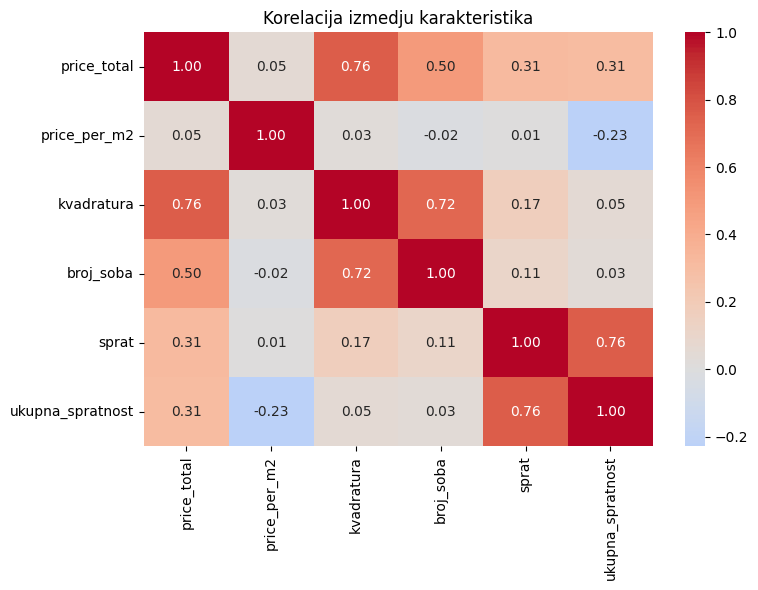

In [51]:
korelacija = df_clean[["price_total","price_per_m2","kvadratura","broj_soba","sprat","ukupna_spratnost"]].corr()

plt.figure(figsize = (8,6))
sns.heatmap(korelacija,annot = True, fmt = ".2f", cmap = "coolwarm",center = 0)
plt.title("Korelacija izmedju karakteristika")
plt.tight_layout()
plt.show()

In [52]:
# Zanimljivo....

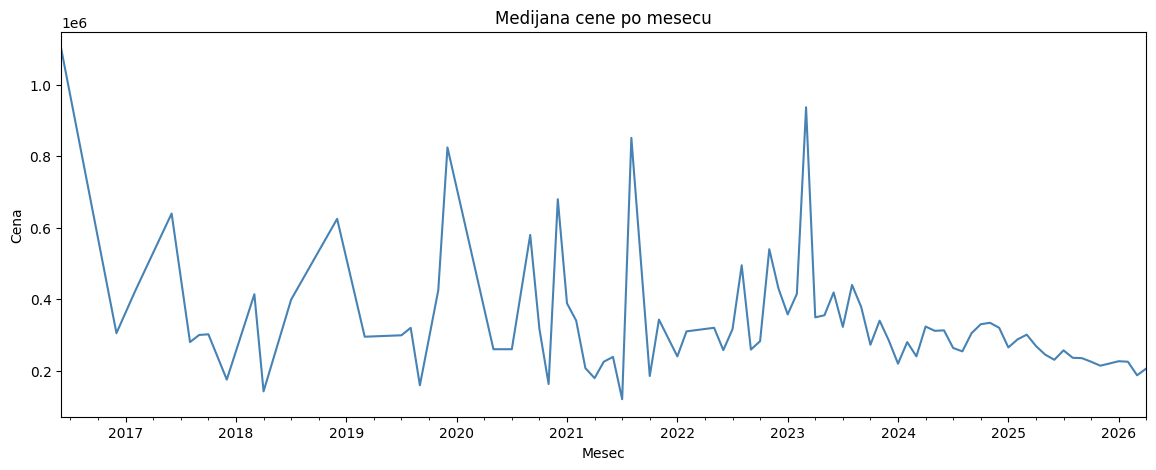

In [56]:
df_clean["datum_objave"] = pd.to_datetime(df_clean["datum_objave"])
df_clean["mesec"] = df_clean["datum_objave"].dt.to_period("M")

trend = df_clean.groupby("mesec")["price_total"].median()

plt.figure(figsize = (14,5))
trend.plot(color = "steelblue")
plt.title("Medijana cene po mesecu")
plt.xlabel("Mesec")
plt.ylabel("Cena")
plt.show()

In [57]:
print(df_clean["datum_objave"].min())
print(df_clean["datum_objave"].max())
print(df_clean.groupby("mesec")["price_total"].count().head(20))

2016-06-29 00:00:00
2026-04-27 00:00:00
mesec
2016-06    1
2016-12    1
2017-02    1
2017-06    2
2017-08    1
2017-09    1
2017-10    2
2017-12    1
2018-03    1
2018-04    4
2018-07    1
2018-12    7
2019-03    1
2019-07    2
2019-08    1
2019-09    1
2019-11    1
2019-12    1
2020-05    1
2020-07    7
Freq: M, Name: price_total, dtype: int64


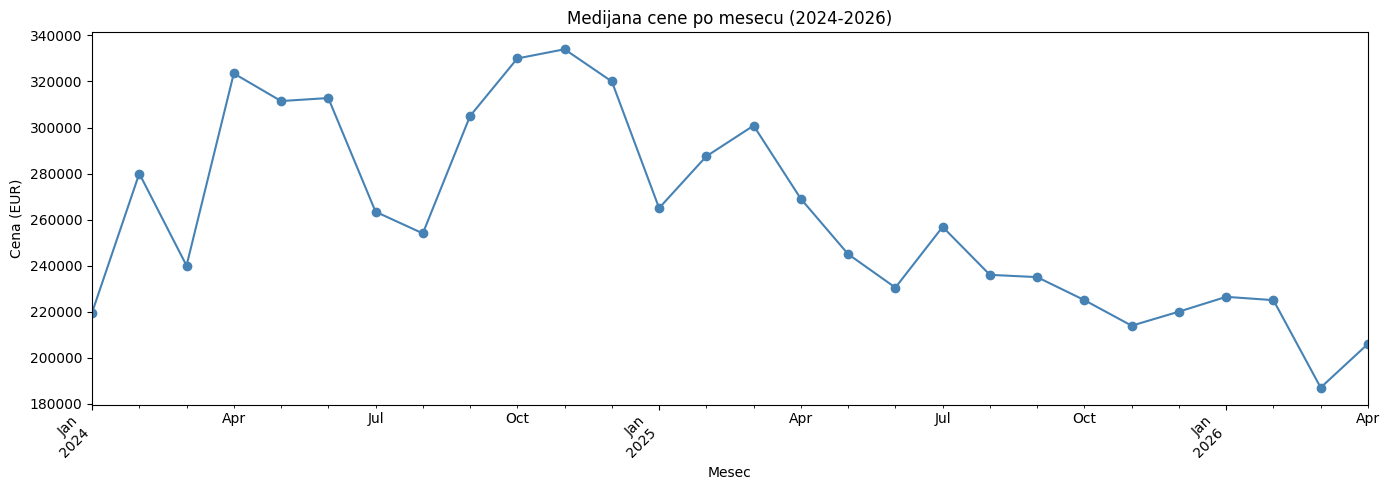

mesec
2024-01      26
2024-02      17
2024-03      19
2024-04      36
2024-05      10
2024-06      23
2024-07      25
2024-08      29
2024-09      47
2024-10      53
2024-11      70
2024-12      49
2025-01      49
2025-02      70
2025-03     120
2025-04     244
2025-05     157
2025-06     174
2025-07     152
2025-08     155
2025-09     523
2025-10     275
2025-11     317
2025-12     358
2026-01     344
2026-02     603
2026-03    1286
2026-04    6602
Freq: M, Name: price_total, dtype: int64


In [58]:
df_trend = df_clean[df_clean["datum_objave"] >= "2024-01-01"]

trend = df_trend.groupby("mesec")["price_total"].median()

plt.figure(figsize=(14, 5))
trend.plot(color="steelblue", marker="o")
plt.title("Medijana cene po mesecu (2024-2026)")
plt.xlabel("Mesec")
plt.ylabel("Cena (EUR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(df_trend.groupby("mesec")["price_total"].count())

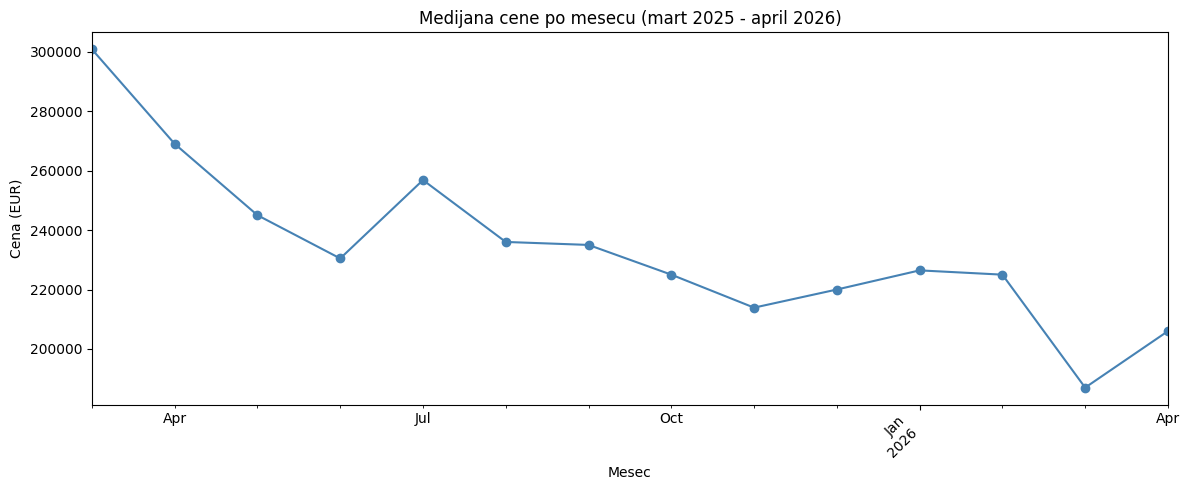

In [59]:
df_trend2 = df_clean[df_clean["datum_objave"] >= "2025-03-01"]

trend2 = df_trend2.groupby("mesec")["price_total"].median()

plt.figure(figsize=(12, 5))
trend2.plot(color="steelblue", marker="o")
plt.title("Medijana cene po mesecu (mart 2025 - april 2026)")
plt.xlabel("Mesec")
plt.ylabel("Cena (EUR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

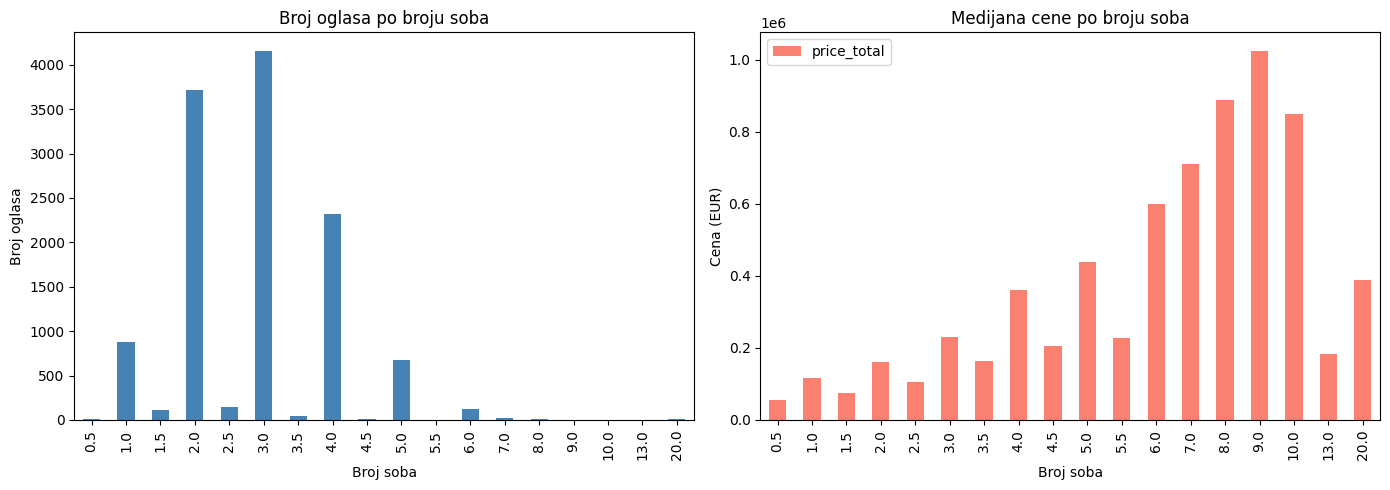

In [72]:
fig, axes = plt.subplots(1,2,figsize =(14,5))

#broj soba po oglasima
sobe_count = df_clean["broj_soba"].value_counts().sort_index()
sobe_count.plot(kind = "bar",ax = axes[0],color = "steelblue")
axes[0].set_title("Broj oglasa po broju soba")
axes[0].set_xlabel("Broj soba")
axes[0].set_ylabel("Broj oglasa")

#medijana cene po broju soba
sobe_cena = df_clean.groupby("broj_soba")[["price_total"]].median()
sobe_cena.plot(kind = "bar", ax = axes[1],color = "salmon")
axes[1].set_title("Medijana cene po broju soba")
axes[1].set_xlabel("Broj soba")
axes[1].set_ylabel("Cena (EUR)")

plt.tight_layout()
plt.show()

In [73]:
print(df_clean["broj_soba"].value_counts().sort_index())
print("\nPo izvoru:")
print(df_clean.groupby("izvor")["broj_soba"].value_counts().sort_index())

broj_soba
0.5       15
1.0      876
1.5      116
2.0     3719
2.5      143
3.0     4157
3.5       50
4.0     2316
4.5       12
5.0      679
5.5        1
6.0      129
7.0       23
8.0       12
9.0        2
10.0       3
13.0       1
20.0       9
Name: count, dtype: int64

Po izvoru:
izvor          broj_soba
halo_oglasi    0.5            10
               1.0            21
               1.5            68
               2.0           122
               2.5            83
               3.0           164
               3.5            24
               4.0            71
               4.5             6
               5.0            52
nekretnine_rs  0.5             5
               1.0           845
               1.5            18
               2.0          3538
               2.5            30
               3.0          3925
               3.5            15
               4.0          2218
               4.5             3
               5.0           606
               6.0           127


In [74]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 12386 entries, 6 to 23430
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   unified_id               12386 non-null  str           
 1   izvor                    12386 non-null  str           
 2   oglas_id                 12386 non-null  str           
 3   url                      12386 non-null  str           
 4   title                    12379 non-null  str           
 5   price_total              12386 non-null  float64       
 6   price_per_m2             12386 non-null  float64       
 7   tip_nekretnine           11884 non-null  str           
 8   kvadratura               12386 non-null  float64       
 9   broj_soba                12263 non-null  float64       
 10  oglasivac                866 non-null    str           
 11  tip_objekta              905 non-null    str           
 12  stanje_objekta           11754 non-null  str    

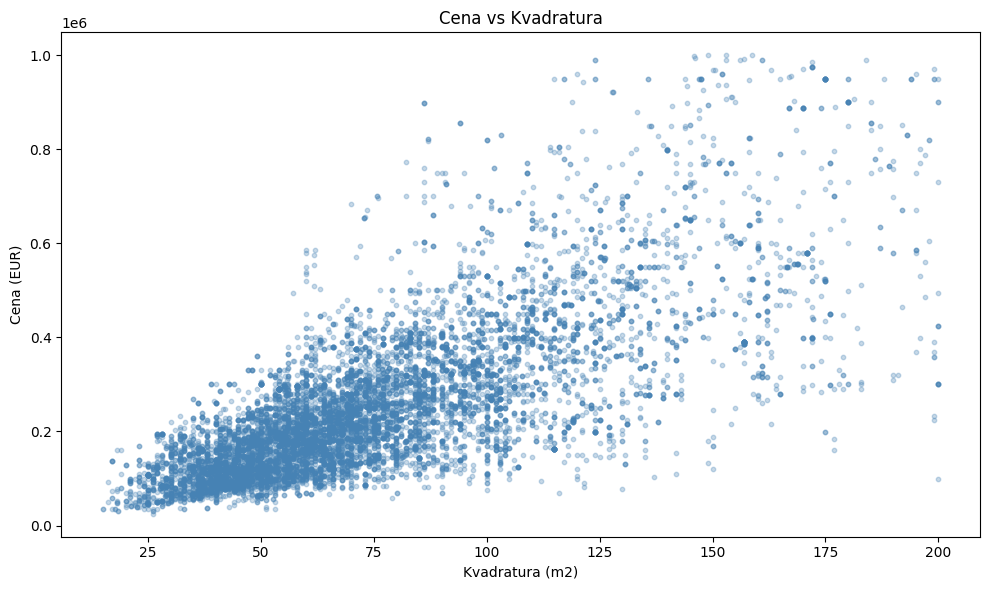

In [84]:
#Ima outliera pa se slika razvlaci
df_scatter = df_clean[
    (df_clean["kvadratura"] <= 200) & 
    (df_clean["price_total"] <= 1000000)
]

plt.figure(figsize= (10,6))
plt.scatter(
    df_scatter["kvadratura"],
    df_scatter["price_total"],
    alpha = 0.3,
    color = "steelblue",
    s = 10
)
plt.title("Cena vs Kvadratura")
plt.xlabel("Kvadratura (m2)")
plt.ylabel("Cena (EUR)")
plt.tight_layout()
plt.show()

oglasivac
Agencija      539
agencija      245
Vlasnik        53
Investitor     29
Name: count, dtype: int64
              median  count
oglasivac                  
Agencija    118000.0    539
Investitor  102960.0     29
Vlasnik     102960.0     53
agencija    111400.0    245


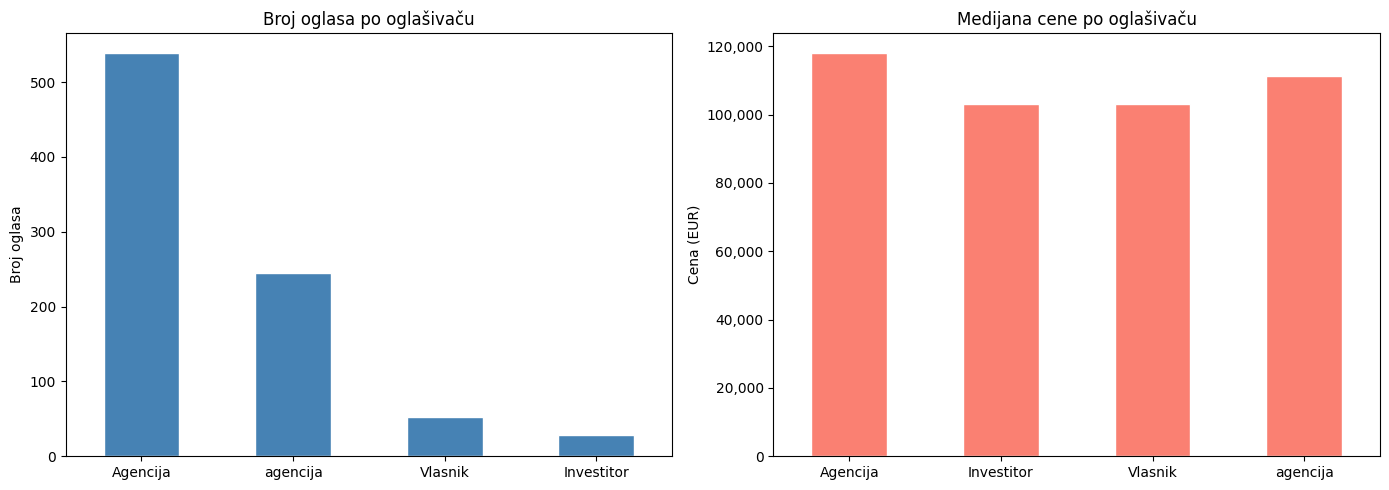

In [86]:
# Distribucija oglasivaca
print(df_clean["oglasivac"].value_counts())

# Medijana cene po oglasivac
oglasivac_cena = df_clean.groupby("oglasivac")["price_total"].agg(["median", "count"])
print(oglasivac_cena)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Broj oglasa
df_clean["oglasivac"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Broj oglasa po oglašivaču")
axes[0].set_xlabel("")
axes[0].set_ylabel("Broj oglasa")
axes[0].tick_params(axis="x", rotation=0)

# Medijana cene
oglasivac_cena["median"].plot(kind="bar", ax=axes[1], color="salmon", edgecolor="white")
axes[1].set_title("Medijana cene po oglašivaču")
axes[1].set_xlabel("")
axes[1].set_ylabel("Cena (EUR)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [87]:
print(df_clean.groupby(["izvor", "oglasivac"])["price_total"].agg(["median", "count"]))

                          median  count
izvor       oglasivac                  
halo_oglasi Agencija    118000.0    539
            Investitor  102960.0     29
            Vlasnik     102960.0     53
z4ida       agencija    111400.0    245


In [88]:
print(df_clean[df_clean["izvor"] == "nekretnine_rs"]["oglasivac"].value_counts(dropna=False))

oglasivac
NaN    11503
Name: count, dtype: int64
